In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [19]:
# Apply the default theme
sns.set_theme()

In [ ]:
#data_url = "https://raw.githubusercontent.com/dthonon/pna_loup_suivi/main/data/"
data_url = "/home/dthonon/Code/pna_loup_suivi/data/"

# Lecture des statistiques agricoles
cheptel_dept = pd.read_excel(data_url + "SAA_2010-2024_définitives_donnees_departementales.xlsx", sheet_name="EFA", skiprows=5)
cheptel_reg = pd.read_excel(data_url + "SAA_2010-2024_définitives_donnees_regionales.xlsx", sheet_name="EFA", skiprows=5)

,LIB_REG2,LIB_SAA,EFF_2010,EFF_2011,EFF_2012,EFF_2013,EFF_2014,EFF_2015,EFF_2016,EFF_2017,EFF_2018,EFF_2019,EFF_2020,EFF_2021,EFF_2022,EFF_2023,EFF_2024
0,FRANCE MÉTROPOLITAINE,01 - Vaches laitières,3712082,3660262,3639469,3693627,3694792,3657531,3630695,3590772,3548634,3484840,3400058,3321276,3230474,3163745,3072881
1,FRANCE MÉTROPOLITAINE,02 - Vaches nourrices,4178610,4103784,4068187,4061958,4100440,4169913,4197235,4108802,4050716,3969890,3930540,3844482,3755654,3707715,3641360
2,FRANCE MÉTROPOLITAINE,03 - Toutes vaches (01 + 02),7890692,7764046,7707656,7755585,7795232,7827444,7827930,7699574,7599350,7454730,7330598,7165758,6986128,6871460,6714241
3,FRANCE MÉTROPOLITAINE,04 - Génisses laitières de renouvellement de p...,756515,716124,679521,695149,702574,712708,700585,735995,690251,645836,599454,543075,515806,508086,492674
4,FRANCE MÉTROPOLITAINE,05 - Génisses nourrices de renouvellement de p...,913220,829893,805639,851730,880512,865048,874014,918038,885956,852078,812583,784231,771704,781123,819869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,976 - Mayotte,31 - Agnelles,0,0,0,0,0,0,140,140,140,140,140,107,107,107,107
696,976 - Mayotte,32 - Brebis-mères (y compris de réforme),0,0,0,0,0,0,700,700,700,700,700,258,258,258,258
697,976 - Mayotte,33 - dont brebis-mères laitières,0,0,0,0,0,0,0,0,0,0,0,31,31,31,31
698,976 - Mayotte,34 - Autres ovins (y compris béliers),0,0,0,0,0,0,165,165,165,165,165,189,189,189,189


Analyse par région

In [77]:
# Filtrer les données pour les ensembles d'espèces bovine, caprine et ovine
ensembles = ['20 - Ensemble espèce bovine (03 + 09 + 15 + 19)', '30 - Ensemble espèce caprine (27 + 28 + 29)', '35 - Ensemble espèce ovine (31 + 32 + 34)']
effectifs = ["EFF_2010", "EFF_2011", "EFF_2012", "EFF_2013", "EFF_2014", "EFF_2015", "EFF_2016", "EFF_2017", "EFF_2018", "EFF_2019", "EFF_2020", "EFF_2021", "EFF_2022", "EFF_2023", "EFF_2024"]
régions = ["11 - Île-de-France", "24 - Centre-Val de Loire", "27 - Bourgogne-Franche-Comté", "28 - Normandie", "32 - Hauts de France", "44 - Grand Est", 
           "52 - Pays de la Loire", "53 - Bretagne", "75 - Nouvelle Aquitaine", "76 - Occitanie", "84 - Auvergne-Rhône-Alpes", "93 - Provence-Alpes-Côte d'Azur"]
pays = "FRANCE MÉTROPOLITAINE"

cheptel_sp_p = cheptel_reg.query("LIB_SAA in @ensembles and LIB_REG2 == @pays")
cheptel_sp_p[effectifs] = cheptel_sp_p[effectifs].div(cheptel_sp_p["EFF_2010"], axis=0) * 100
cheptel_sp_p_melted = cheptel_sp_p.melt(id_vars=["LIB_SAA", "LIB_REG2"], value_vars=effectifs, var_name="Année", value_name="Effectif")
cheptel_sp_p_melted["Année"] = cheptel_sp_p_melted["Année"].str.replace("EFF_", "").astype(int)
cheptel_sp_p_melted["Espèce"] = cheptel_sp_p_melted["LIB_SAA"].apply(lambda x : "Bovins" if "bovine" in x else ("Caprins" if "caprine" in x else "Ovins") )

cheptel_sp_r = cheptel_reg.query("LIB_SAA in @ensembles and LIB_REG2 in @régions")
cheptel_sp_r[effectifs] = cheptel_sp_r[effectifs].div(cheptel_sp_r["EFF_2010"], axis=0) * 100
cheptel_sp_r_melted = cheptel_sp_r.melt(id_vars=["LIB_SAA", "LIB_REG2"], value_vars=effectifs, var_name="Année", value_name="Effectif")
cheptel_sp_r_melted["Année"] = cheptel_sp_r_melted["Année"].str.replace("EFF_", "").astype(int)
cheptel_sp_r_melted["Espèce"] = cheptel_sp_r_melted["LIB_SAA"].apply(lambda x : "Bovins" if "bovine" in x else ("Caprins" if "caprine" in x else "Ovins") )

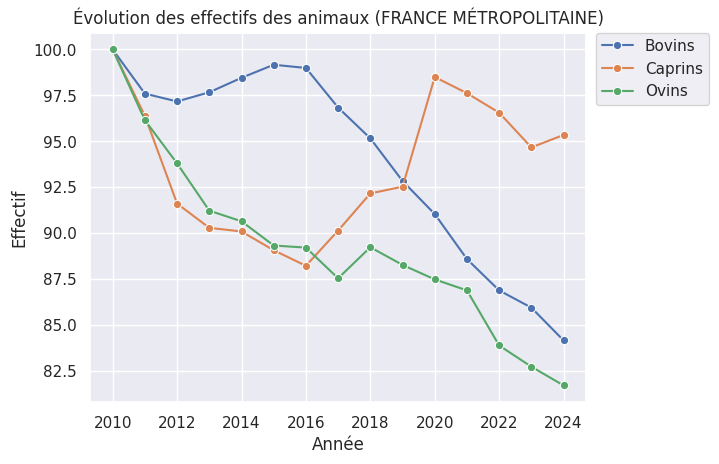

In [78]:
sns.lineplot(data=cheptel_sp_p_melted, x="Année", y="Effectif", hue="Espèce", marker="o").set(title=f"Évolution des effectifs des animaux ({pays})");
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);
plt.show()

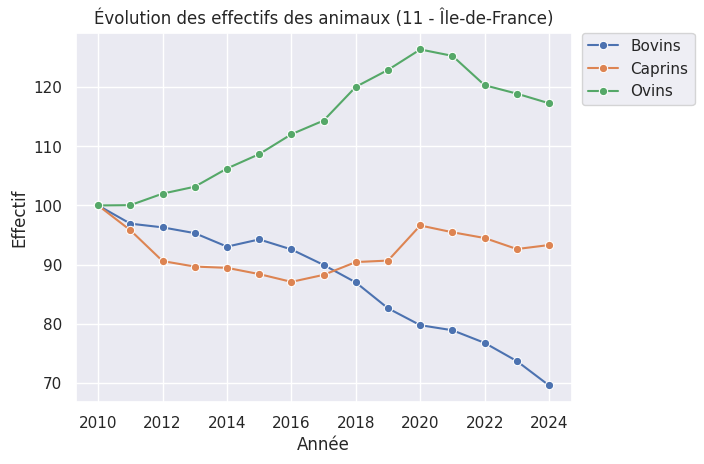

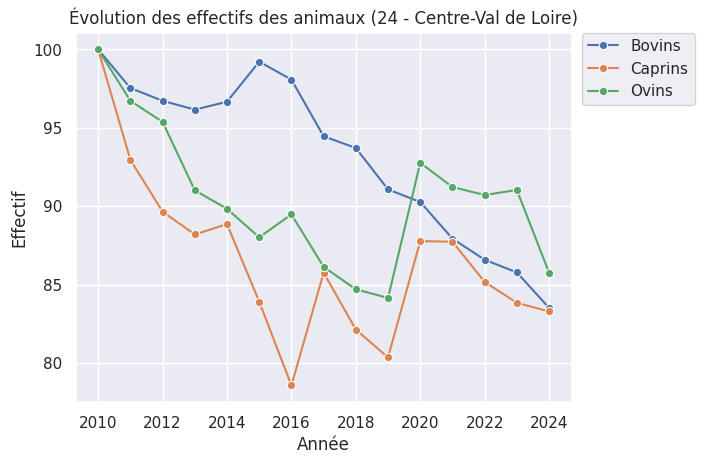

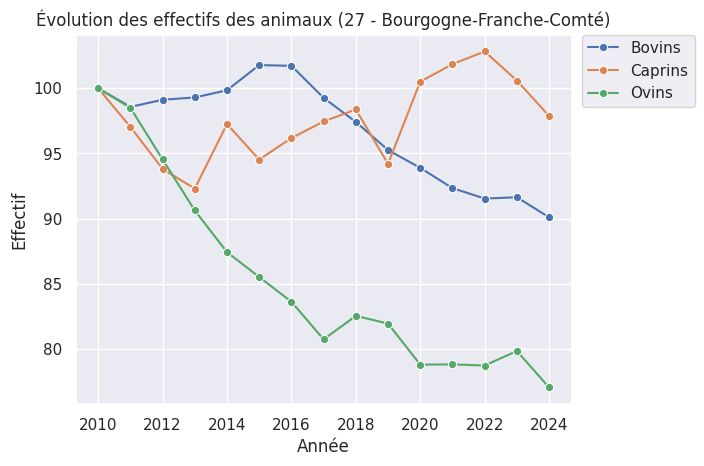

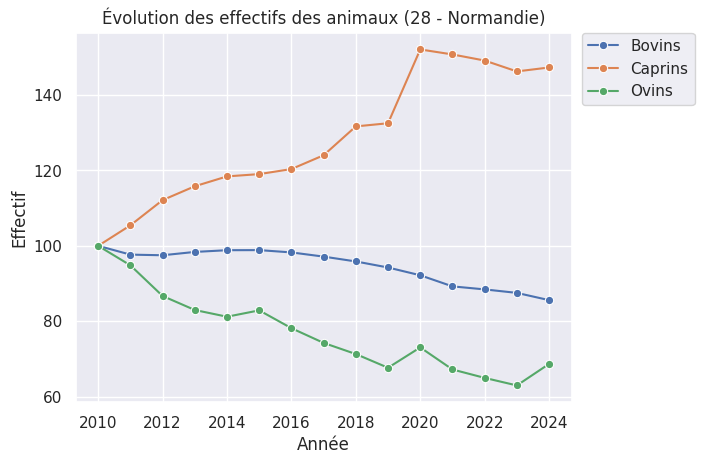

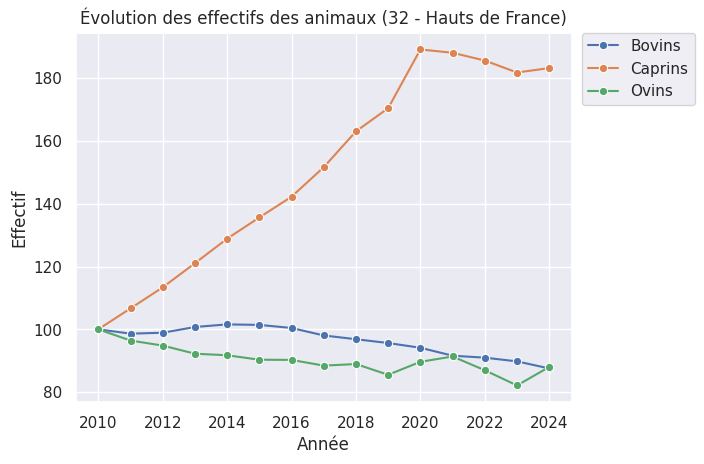

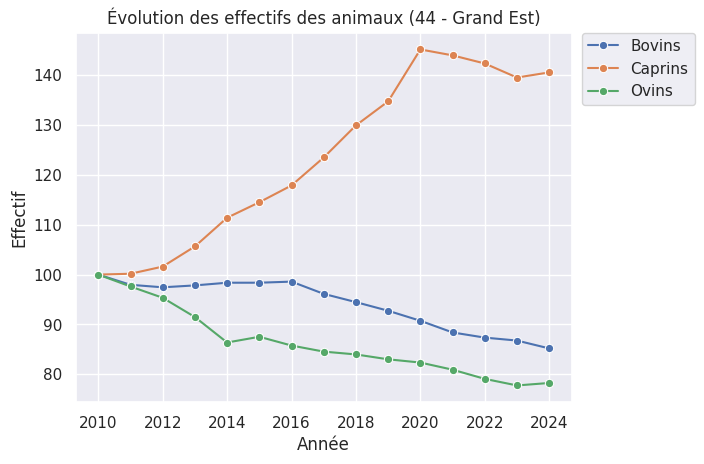

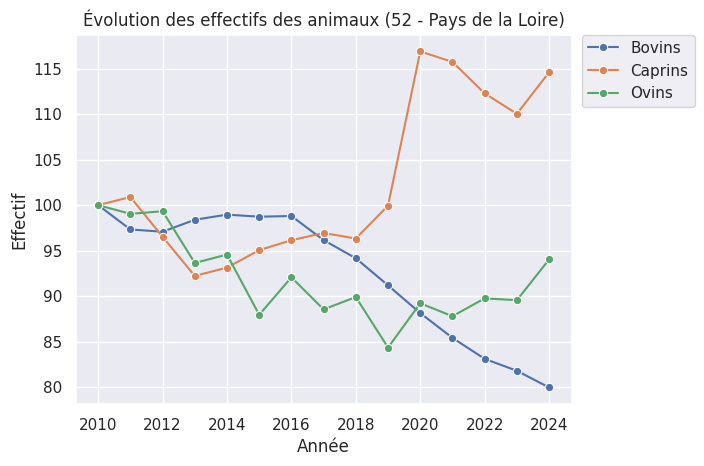

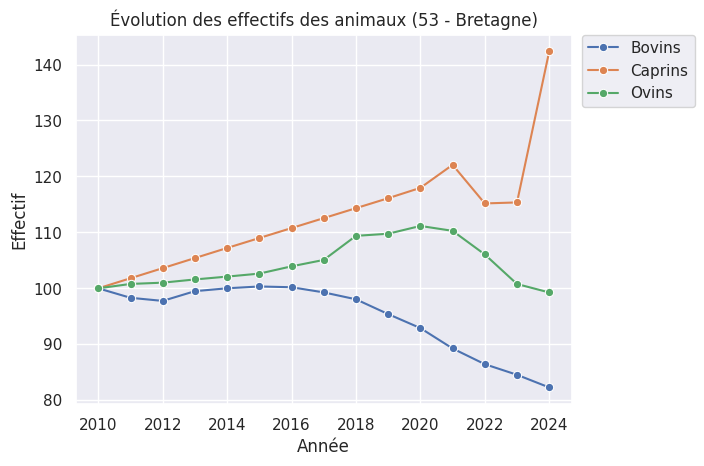

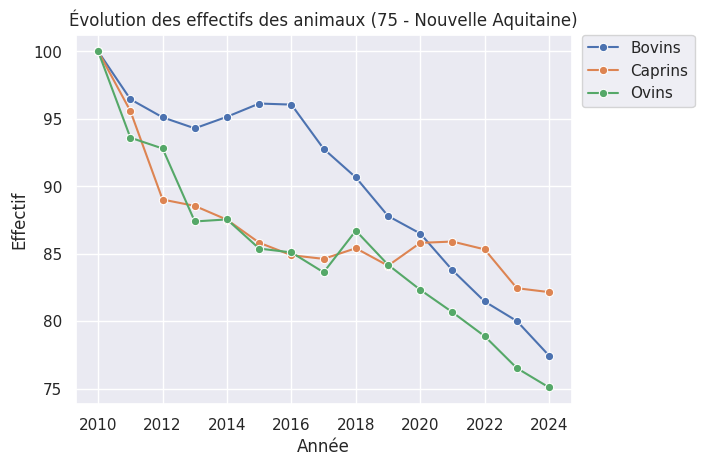

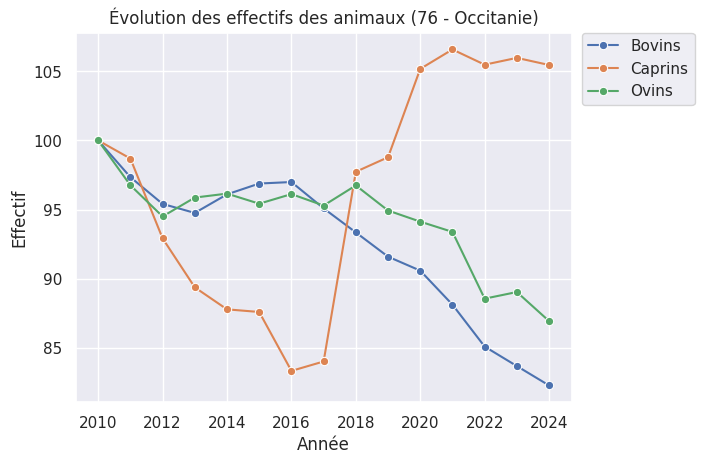

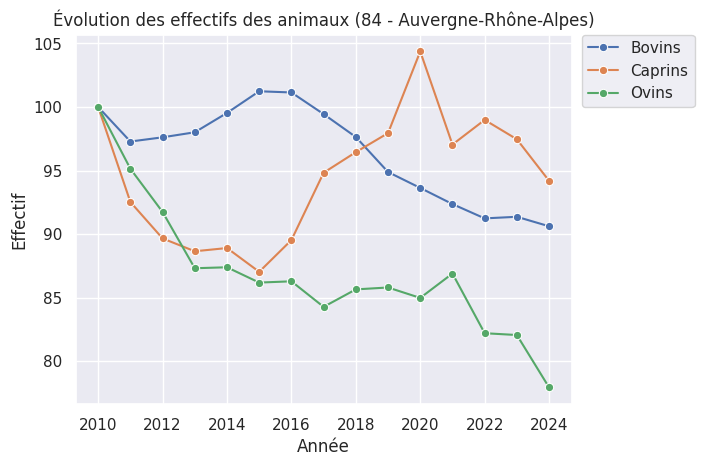

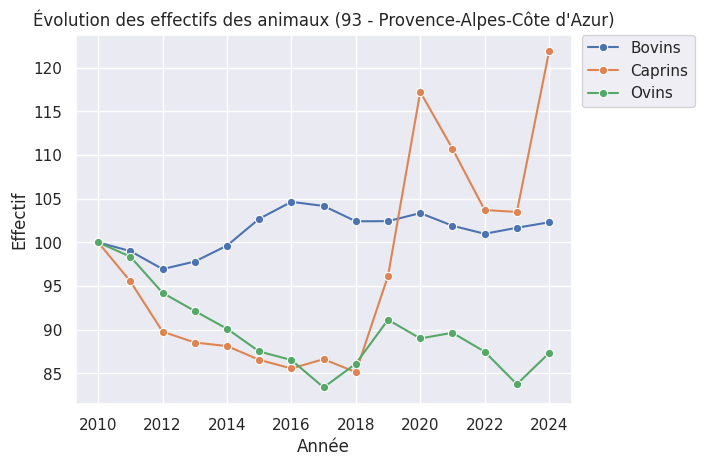

In [79]:
for d in régions:
    filtered_data = cheptel_sp_r_melted[cheptel_sp_r_melted["LIB_REG2"] == d]
    sns.lineplot(data=filtered_data, x="Année", y="Effectif", hue="Espèce", marker="o").set(title=f"Évolution des effectifs des animaux ({d})");
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);
    plt.show()

Analyse par département

In [ ]:
# Filtrer les données pour les ensembles d'espèces bovine, caprine et ovine
cheptel_sp_d = cheptel_dept.query("LIB_SAA in @ensembles")
cheptel_sp_d[effectifs] = cheptel_sp_d[effectifs].div(cheptel_sp_d["EFF_2010"], axis=0) * 100
cheptel_sp_d_melted = cheptel_sp_d.melt(id_vars=["LIB_SAA", "LIB_DEP"], value_vars=effectifs, var_name="Année", value_name="Effectif")
cheptel_sp_d_melted["Année"] = cheptel_sp_d_melted["Année"].str.replace("EFF_", "").astype(int)
cheptel_sp_d_melted["Espèce"] = cheptel_sp_d_melted["LIB_SAA"].apply(lambda x : "Bovins" if "bovine" in x else ("Caprins" if "caprine" in x else "Ovins") )

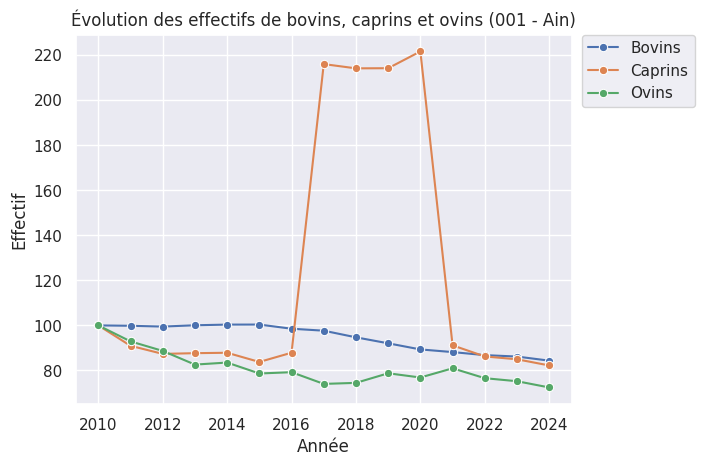

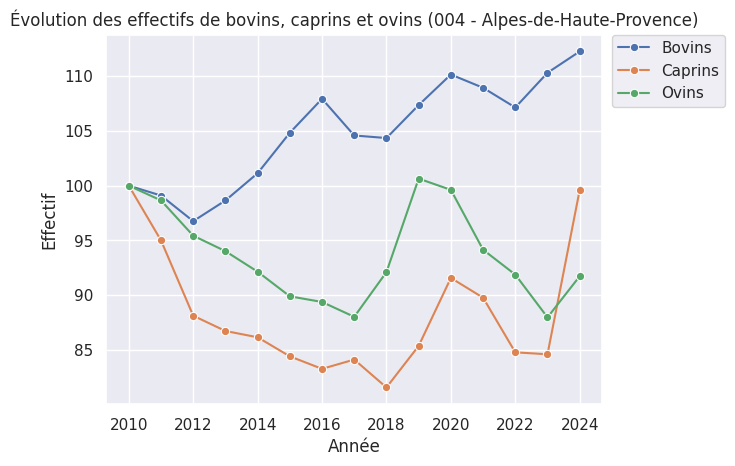

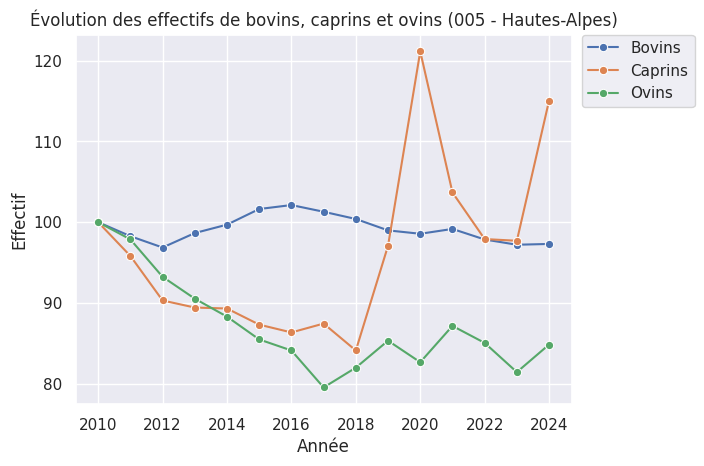

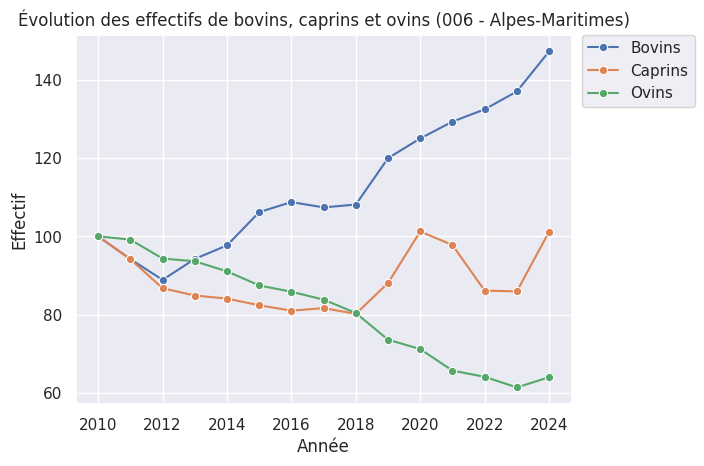

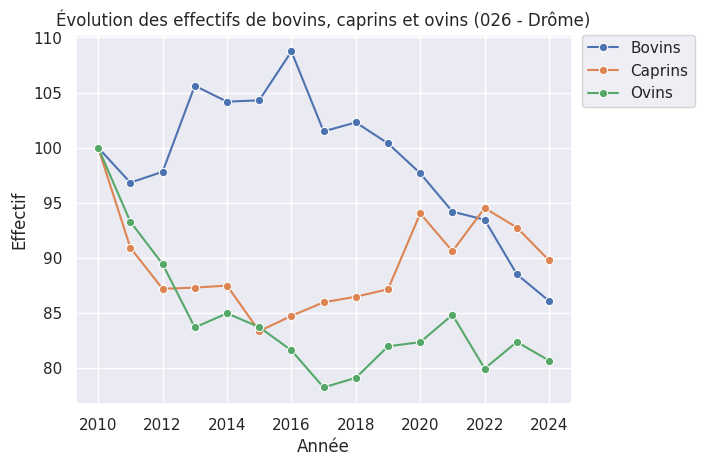

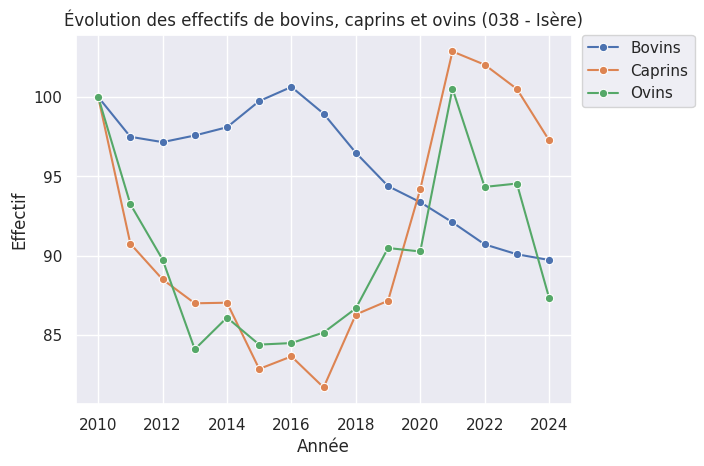

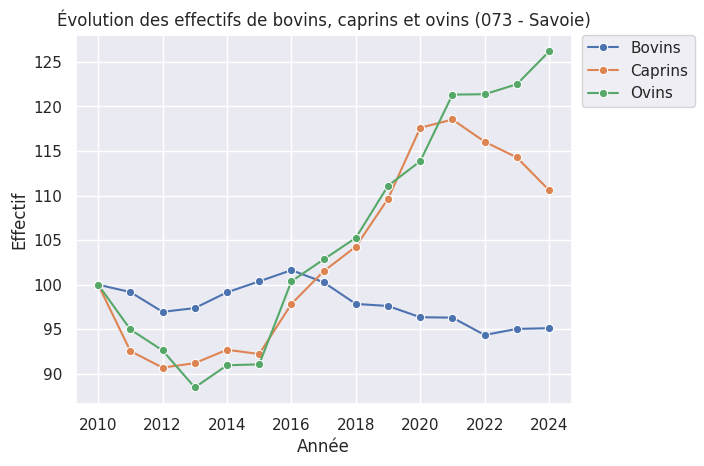

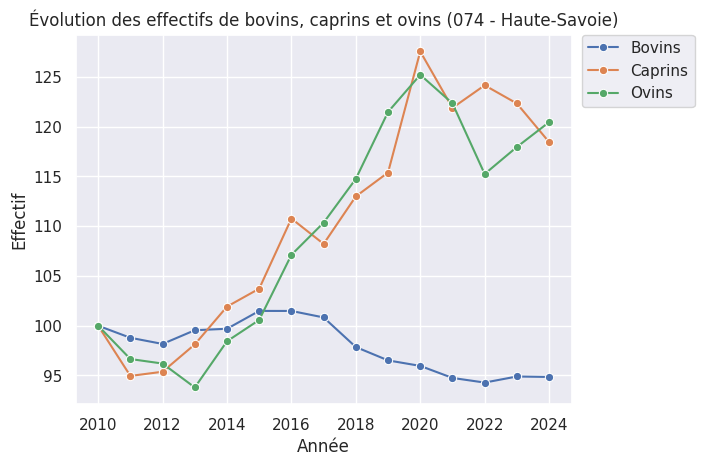

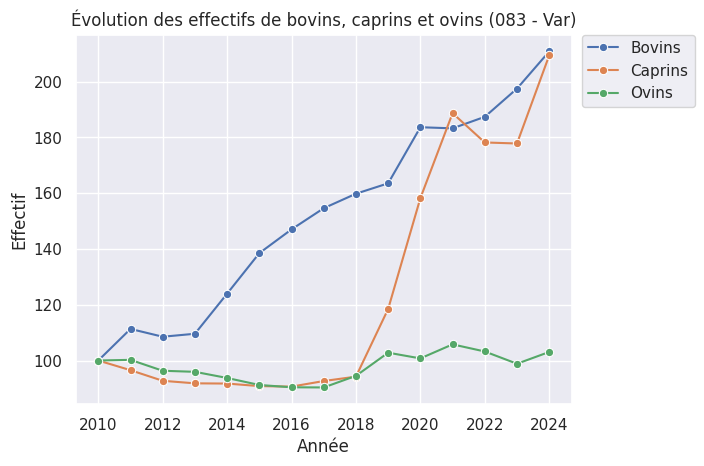

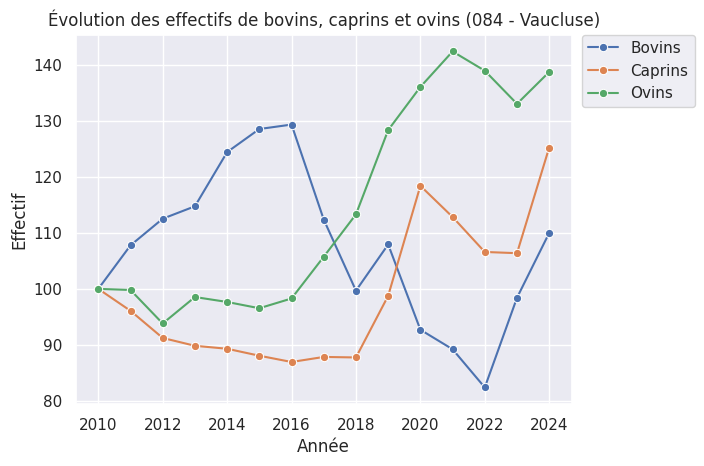

In [ ]:
dept = ["001 - Ain", "004 - Alpes-de-Haute-Provence", "005 - Hautes-Alpes", "006 - Alpes-Maritimes", 
        "026 - Drôme", "038 - Isère", "073 - Savoie", "074 - Haute-Savoie", "083 - Var", "084 - Vaucluse"]
for d in dept:
    filtered_data = cheptel_sp_d_melted[cheptel_sp_d_melted["LIB_DEP"] == d]
    sns.lineplot(data=filtered_data, x="Année", y="Effectif", hue="Espèce", marker="o").set(title=f"Évolution des effectifs de bovins, caprins et ovins ({d})");
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0);
    plt.show()